In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/WineQT.csv")

In [8]:
print(df.info())
print(df.describe())
print(df.shape)
print(df.columns)

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
None
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


In [10]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [11]:
df.nunique()

fixed acidity             91
volatile acidity         135
citric acid               77
residual sugar            80
chlorides                131
free sulfur dioxide       53
total sulfur dioxide     138
density                  388
pH                        87
sulphates                 89
alcohol                   61
quality                    6
Id                      1143
dtype: int64

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

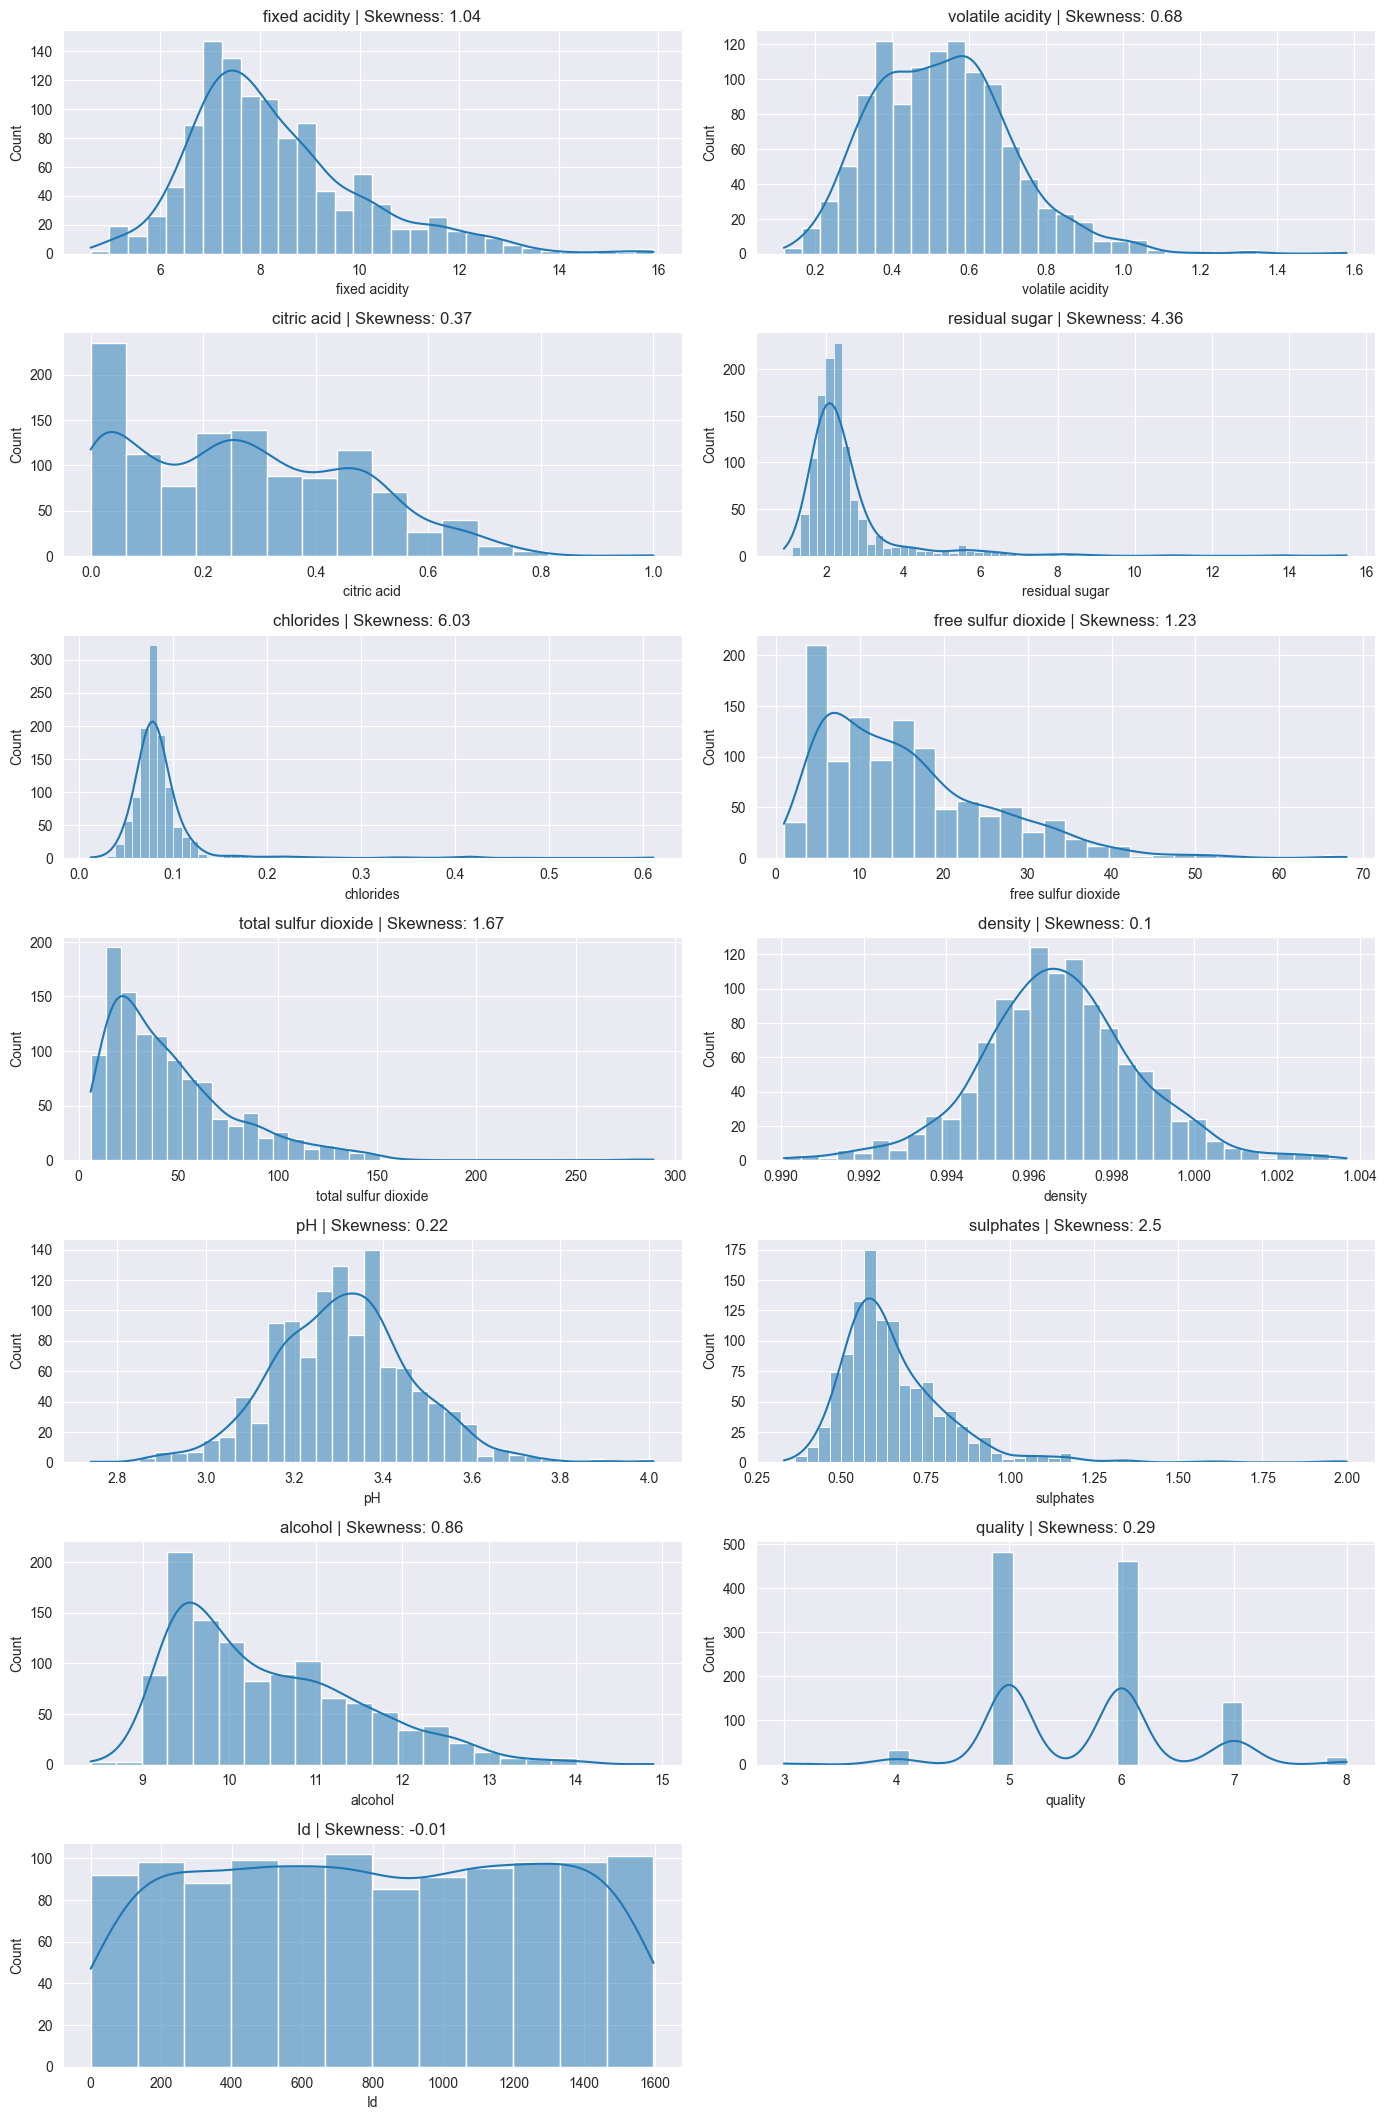

In [15]:
sns.set_style("darkgrid")

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

C:\Users\antoi\AppData\Local\Temp\ipykernel_47784\2757741509.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x="quality", y="alcohol", data=df, palette='viridis')
c:\Users\antoi\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 38.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\antoi\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


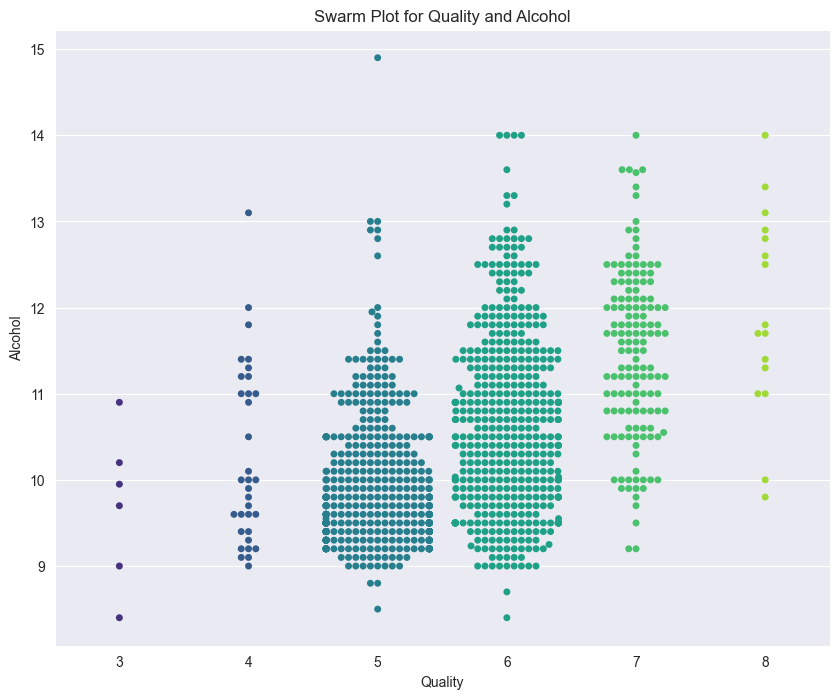

In [19]:
plt.figure(figsize=(10, 8))

sns.swarmplot(x="quality", y="alcohol", data=df, palette='viridis')

plt.title('Swarm Plot for Quality and Alcohol')
plt.xlabel('Quality')
plt.ylabel('Alcohol')
plt.show()

<Axes: xlabel='quality', ylabel='alcohol'>

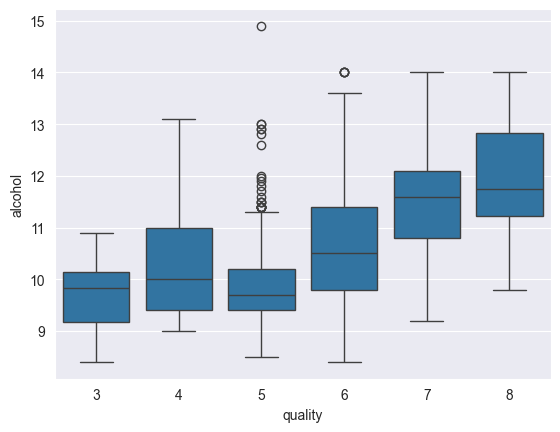

In [20]:
sns.boxplot(x='quality', y='alcohol', data=df)

In [23]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

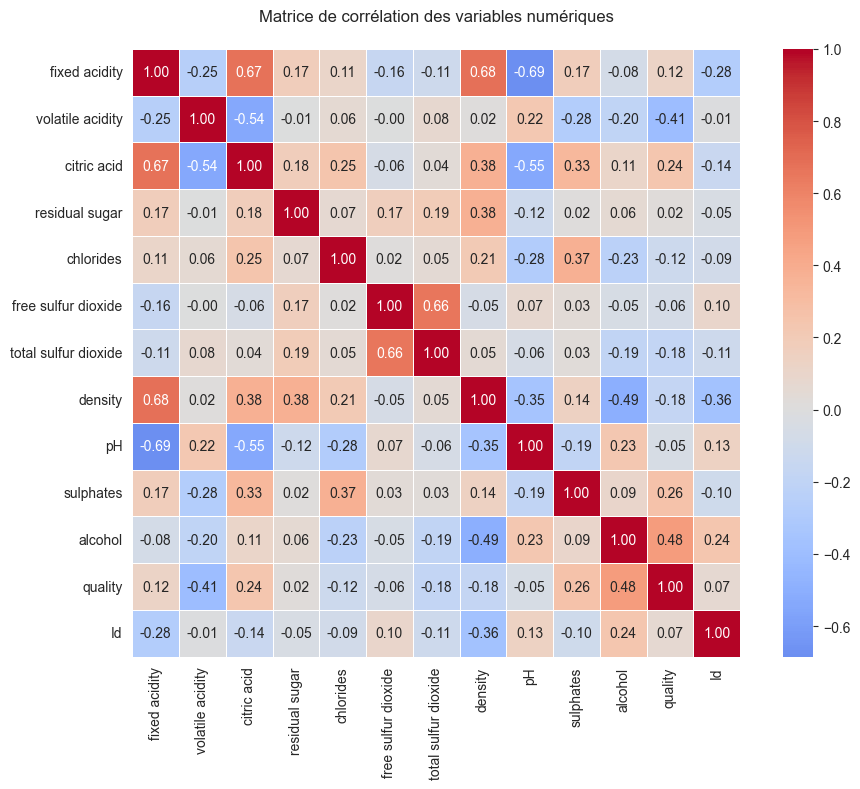

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sélectionner uniquement les colonnes numériques
numerical_df = df.select_dtypes(include=["int64", "float64"])

# Calculer la matrice de corrélation
corr_matrix = numerical_df.corr()

# Créer une heatmap avec Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # Affiche les valeurs dans les cases
    fmt=".2f",           # Formate les valeurs à 2 décimales
    cmap="coolwarm",     # Échelle de couleurs (bleu/rouge)
    center=0,            # Centre l'échelle à 0
    linewidths=0.5,     # Ajoute des lignes entre les cases
    cbar=True,           # Affiche la barre de couleur
    square=True,         # Force un carré pour la heatmap
)

# Ajouter un titre
plt.title("Matrice de corrélation des variables numériques", pad=20)

# Afficher la heatmap
plt.tight_layout()
plt.show()

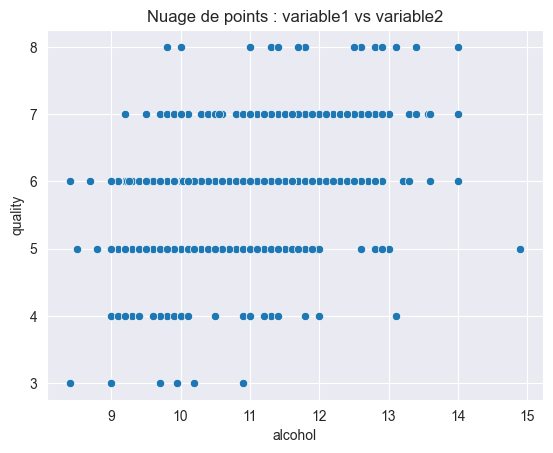

In [26]:
sns.scatterplot(data=df, x="alcohol", y="quality")
plt.title("Nuage de points : variable1 vs variable2")
plt.show()

In [27]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Exemple pour une colonne
outliers = detect_outliers_iqr(df, "quality")
print(f"Outliers dans 'colonne_numerique' :\n{outliers}")

Outliers dans 'colonne_numerique' :
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
190             7.9             0.350         0.46             3.6      0.078   
197            10.3             0.320         0.45             6.4      0.073   
271             5.6             0.850         0.05             1.4      0.045   
310            12.6             0.310         0.72             2.2      0.072   
321            11.3             0.620         0.67             5.2      0.086   
324            11.6             0.580         0.66             2.2      0.074   
340             9.4             0.300         0.56             2.8      0.080   
349            10.7             0.350         0.53             2.6      0.070   
352            10.7             0.350         0.53             2.6      0.070   
368            10.4             0.610         0.49             2.1      0.200   
419             5.0             0.420         0.24             2.0      0

In [28]:
from scipy import stats

def detect_outliers_zscore(df, column, threshold=3):
    z_scores = stats.zscore(df[column])
    outliers = df[abs(z_scores) > threshold]
    return outliers

outliers = detect_outliers_zscore(df, "quality")
print(f"Outliers (Z-Score) :\n{outliers}")

Outliers (Z-Score) :
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
324            11.6             0.580         0.66             2.2      0.074   
368            10.4             0.610         0.49             2.1      0.200   
922             7.6             1.580         0.00             2.1      0.137   
1046            7.3             0.980         0.05             2.1      0.061   
1055            7.1             0.875         0.05             5.7      0.082   
1074            6.7             0.760         0.02             1.8      0.078   

      free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
324                  10.0                  47.0  1.00080  3.25       0.57   
368                   5.0                  16.0  0.99940  3.16       0.63   
922                   5.0                   9.0  0.99476  3.50       0.40   
1046                 20.0                  49.0  0.99705  3.31       0.55   
1055                  3.0 